In [3]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import glob
import pandas as pd 
import scipy as sp 
import scipy.stats as sps
import astropy
from astropy.io import fits
from scipy.stats import poisson
import statsmodels as sm
from scipy.special import gammaln
from matplotlib.ticker import MultipleLocator, AutoMinorLocator


# colors 
# special plot params
plt.style.use('dark_background')
plt.rcParams['axes.facecolor'] = 'midnightblue'
plt.rcParams['figure.facecolor'] = "#060552"
plt.rcParams['axes.grid'] = 'True'
plt.rcParams['grid.color'] = 'steelblue'
plt.rcParams['grid.linewidth'] = 0.6
plt.rcParams['grid.alpha'] = 0.8
plt.rcParams['axes.edgecolor'] = 'white'
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['legend.facecolor'] = "#060552"



### Making this notebook to just combine the place to do both the median and then calculate the EW

##### NOTE: this is all POST normalization

---

##### Define Functions: 

In [8]:
def import_txts_get_arrays(data_dir_path, folder_in_data_dir):  # this argument is a string
    '''
    This function: takes files from .txt in the data directory
    that holds the files that were output from the fits_to_txt_v3.py
    and takes those files, loads them in as numpy arrays, and then 
    creates an output of 2D wavelength arrays and flux arrays 
    
    input: 
    - exact folder where the data was originally (the "full" is included in the function) 
    output: 
    - 2 2D arrays 

    need to change per person: 
    - data_dir_path: wherever your general "data" folder is living, could look like: 
    '/Users/leayamashiro/AnA_MSc/Observations/LaPalma_analysis/data/', or 
    this should actually work well: (just change everything before lapalma_analysis/data)
    '/Users/leayamashiro/AnA_MSc/Observations/git/lapalma_analysis/data/' 
    - folder_in_data_dir: this is the exact folder where the .txt files output from the 
     fits_to_txt files live. so this will change with each night of observation. 
     for example, this would just be simply: 'our_data051026'
    '''
    files_glob = glob.glob(str(data_dir_path) + folder_in_data_dir + '/full/*.txt') # just collects all filenames in a big string
    # make empty arrays 
    wavelength_arrays = []
    flux_arrays = []
    spectra = []
    # get all files, load in as numpy arrays, and then sort into lists
    # yes it is redundant, but in 
    for file in files_glob: 
        spectrum = np.loadtxt(file)
        spectrum_wavelength = spectrum[:,0]
        spectrum_flux = spectrum[:,1]
        wavelength_arrays.append(spectrum_wavelength)
        flux_arrays.append(spectrum_flux)
        spectra.append(spectrum)
    return wavelength_arrays, flux_arrays, spectra, 


# this is using the output of import_txts_get_arrays as input.
# this is also just to check the length of the spectra
def check_length_all_spectra(wavelength_arrays): 
    for i in range(len(wavelength_arrays)): 
        wavelength_array = wavelength_arrays[i]
        print(len(wavelength_array))


# interpolate the spectra on the wavelength array from the first of three exposures
def interpolate_spectra(spectra):  
    # where spectra is an array of spectra that came out of the import .txt function
    wl_ref = spectra[0][:, 0] # reference wavelength array as just the first of the three (NOTE: we may change this) 
    interpolated_fluxes = [] # make empty list for all the interpolated fluxes 
    for i in range(len(spectra)): # iterate through the spectra 
        wl = spectra[i][:, 0] 
        flux = spectra[i][:, 1] 
        # interpolate on the reference axix
        aligned_flux = np.interp(x = wl_ref, 
                                xp = wl, 
                                fp = flux)
        # append to array for interpolated fluxes     
        interpolated_fluxes.append(aligned_flux)            
    return wl_ref, interpolated_fluxes


# get the mean of interpolated spectra
def get_mean_spectra(interpolated_fluxes): 
    mean_fluxes_interp = np.mean(interpolated_fluxes, axis=0)
    return mean_fluxes_interp


# save as .txt in the same format that is needed for the normalization script
def save_mean_txt(wl_ref, mean_fluxes_interp, end_filename, data_dir_path, folder_in_data_dir): # input is the median interpolated spectra
    # I have been saving things as median_combined_051026.txt... etc
    mean_output_file = str(data_dir_path) + str(folder_in_data_dir) + '/full_median/' + str(end_filename) + '.txt'
    np.savetxt(mean_output_file, 
               np.column_stack((wl_ref, mean_fluxes_interp)),
               fmt="%.8f %.10e")



trying out first batch of functions: 

In [9]:
wl_arrs, flux_arrs, spec_arrs = import_txts_get_arrays(data_dir_path='/Users/leayamashiro/AnA_MSc/Observations/git/lapalma_analysis/data/', 
                                                       folder_in_data_dir='our_data051026')

In [10]:
spec_arrs[0]

array([[ 3.77312406e+03, -2.51000000e+00],
       [ 3.77314368e+03, -3.82000000e+00],
       [ 3.77316331e+03, -2.74000000e+00],
       ...,
       [ 9.00665234e+03,  9.80770000e+02],
       [ 9.00669918e+03,  1.02843000e+03],
       [ 9.00674602e+03,  1.12606000e+03]], shape=(167306, 2))

Success! Next: 

In [11]:
%matplotlib qt

In [12]:
wl_ref, fluxes_interp = interpolate_spectra(spec_arrs)
# just plotting to make sure they are all spectra still, in full range of HERMES
plt.plot(wl_ref, fluxes_interp[0], label = 'spectra 1')
plt.plot(wl_ref, fluxes_interp[1], label = 'spectra 2')
plt.plot(wl_ref, fluxes_interp[2], label = 'spectra 3')
plt.legend()

Success Again! 

In [13]:
mean_spec = get_mean_spectra(fluxes_interp)
mean_spec

array([  -2.67666667,   -3.97      ,   -3.93333333, ...,  933.63      ,
        967.62666667, 1059.32666667], shape=(167306,))

Try out the saving as .txt function

In [17]:
save_mean_txt(wl_ref = wl_ref, 
                mean_fluxes_interp = mean_spec, 
                end_filename = 'saving_mean_test', 
                data_dir_path = '/Users/leayamashiro/AnA_MSc/Observations/git/lapalma_analysis/analysis_LY/data_LY/', 
                folder_in_data_dir='our_data051026')

#### Now making big function to do it all at once: 

In [16]:
def txt_to_mean_txt_total(data_dir_path, folder_in_data_dir, # for use of import_txts_get_arrays function
                            end_filename, # for use of the final csv saving.
                            check_lengths=False):

                            wavelength_arrays, flux_arrays, spectra = import_txts_get_arrays(data_dir_path, folder_in_data_dir)

                            if check_lengths==True: 
                                    check_length_all_spectra(wavelength_arrays)
                                    wl_ref, interpolated_fluxes = interpolate_spectra(spectra)
                                    median_fluxes_interp = get_mean_spectra(interpolated_fluxes)
                                    save_mean_txt(wl_ref, median_fluxes_interp, end_filename, data_dir_path, folder_in_data_dir)

                            else:   
                                wl_ref, interpolated_fluxes = interpolate_spectra(spectra)
                                median_fluxes_interp = get_mean_spectra(interpolated_fluxes)
                                save_mean_txt(wl_ref, median_fluxes_interp, end_filename, data_dir_path, folder_in_data_dir)

In [ ]:
txt_to_mean_txt_total(data_dir_path = '/Users/leayamashiro/AnA_MSc/Observations/git/lapalma_analysis/data/', 
                        folder_in_data_dir='our_data051026', 
                        end_filename = 'saving_median_test_2.txt', 
                        check_lengths=True)

167306
167306
167307


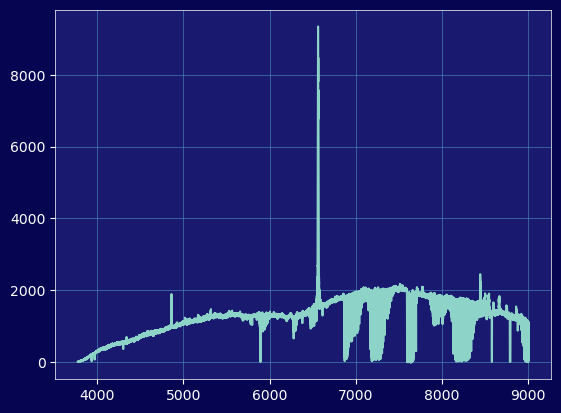

In [71]:
test_median_file = '/Users/leayamashiro/AnA_MSc/Observations/git/lapalma_analysis/data/our_data051026/full_median/saving_median_test_2.txt'
test_file = np.loadtxt(test_median_file)

plt.plot(test_file[:,0], test_file[:,1])